In [1]:
import numpy as np 
import pandas as pd
pd.set_option('display.max_columns',None)

In [2]:
train_data = pd.read_csv('train.csv')
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [3]:
#separating the categorical features and numerical features
num_cols = list(set(train_data.describe().columns.to_list()) - set(['Id']))
cat_cols = list(set(train_data.columns.to_list()) - set(num_cols) - set(['Id']))

In [4]:
len(num_cols)

37

array([[<Axes: title={'center': 'TotRmsAbvGrd'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': '3SsnPorch'}>],
       [<Axes: title={'center': 'SalePrice'}>,
        <Axes: title={'center': 'GarageYrBlt'}>,
        <Axes: title={'center': 'MoSold'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'Fireplaces'}>,
        <Axes: title={'center': 'PoolArea'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': 'WoodDeckSF'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'GarageArea'}>],
       [<Axes: title={'center': 'MiscVal'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'GrLivArea'}>, <Axes: >]], dtype=object)

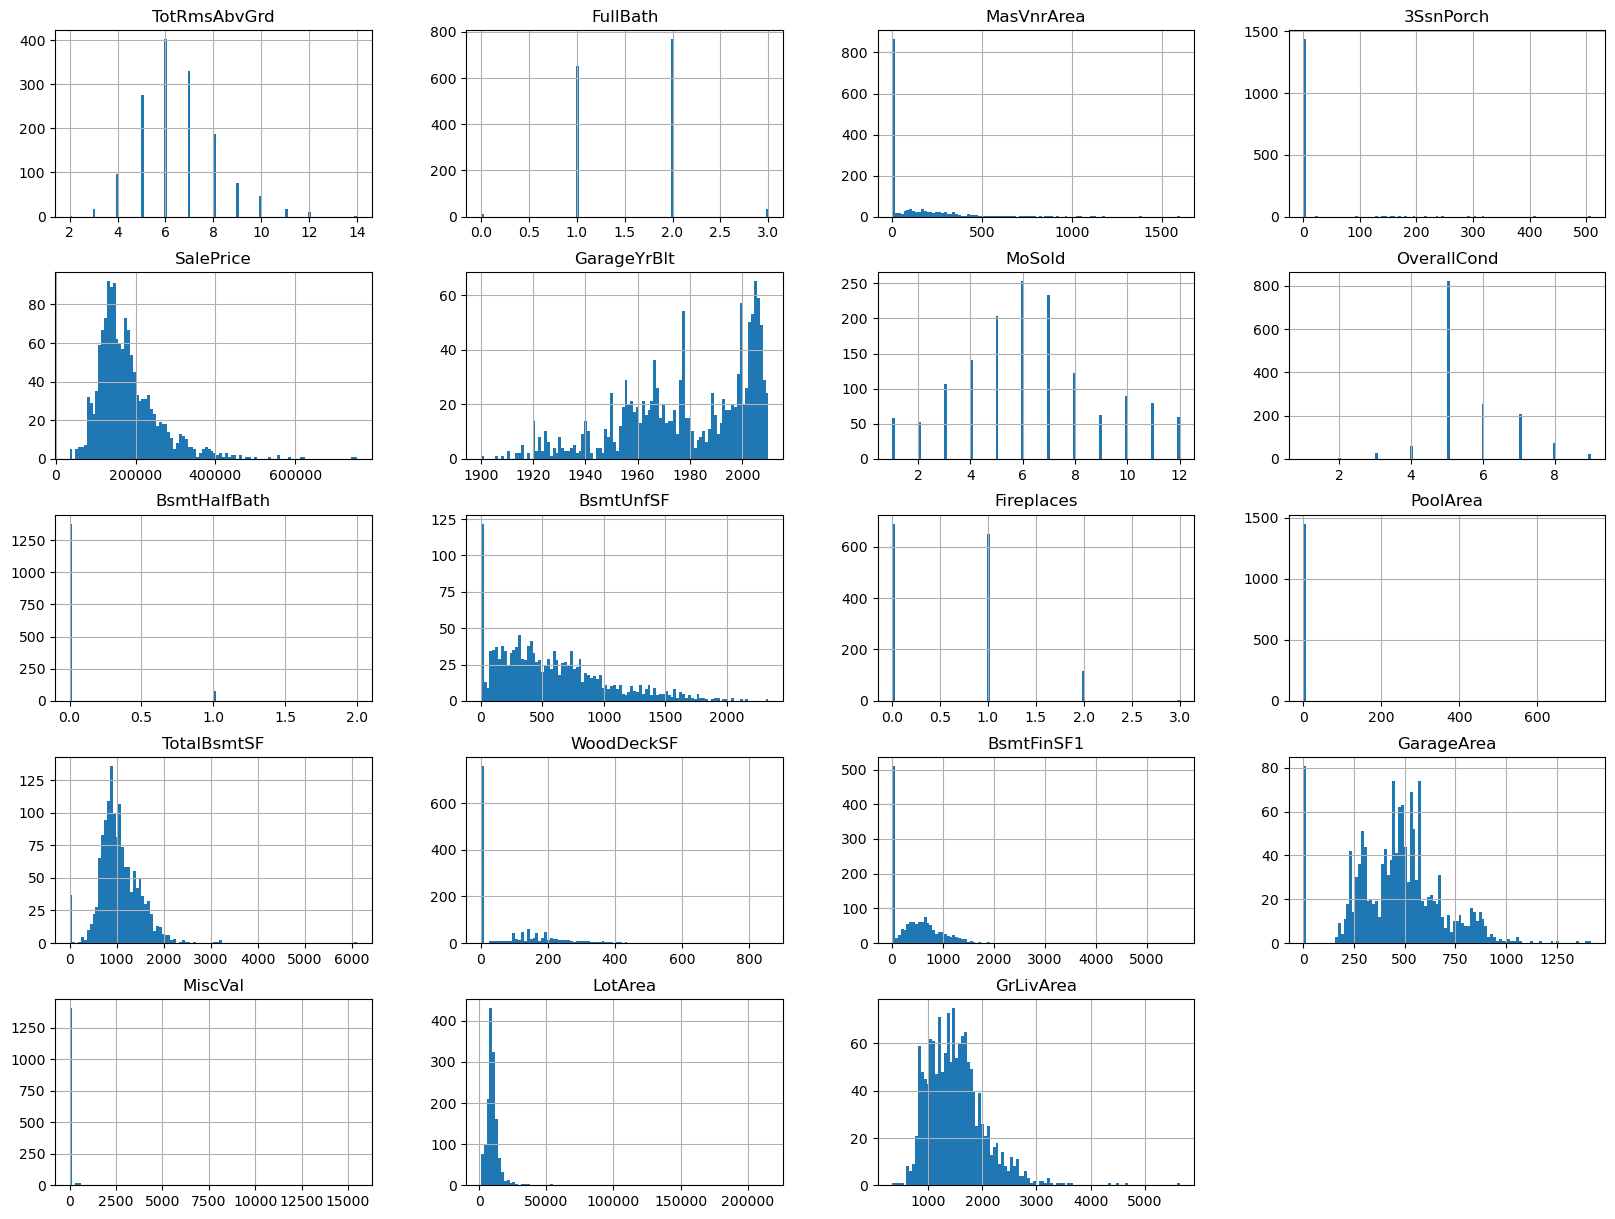

In [5]:
import matplotlib.pyplot as plt
train_data[num_cols[:19]].hist(bins=100,figsize=(20,15))

array([[<Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'BedroomAbvGr'}>,
        <Axes: title={'center': 'KitchenAbvGr'}>],
       [<Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'EnclosedPorch'}>,
        <Axes: title={'center': 'GarageCars'}>,
        <Axes: title={'center': 'YearRemodAdd'}>],
       [<Axes: title={'center': 'YrSold'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'OverallQual'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': '2ndFlrSF'}>],
       [<Axes: title={'center': 'ScreenPorch'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

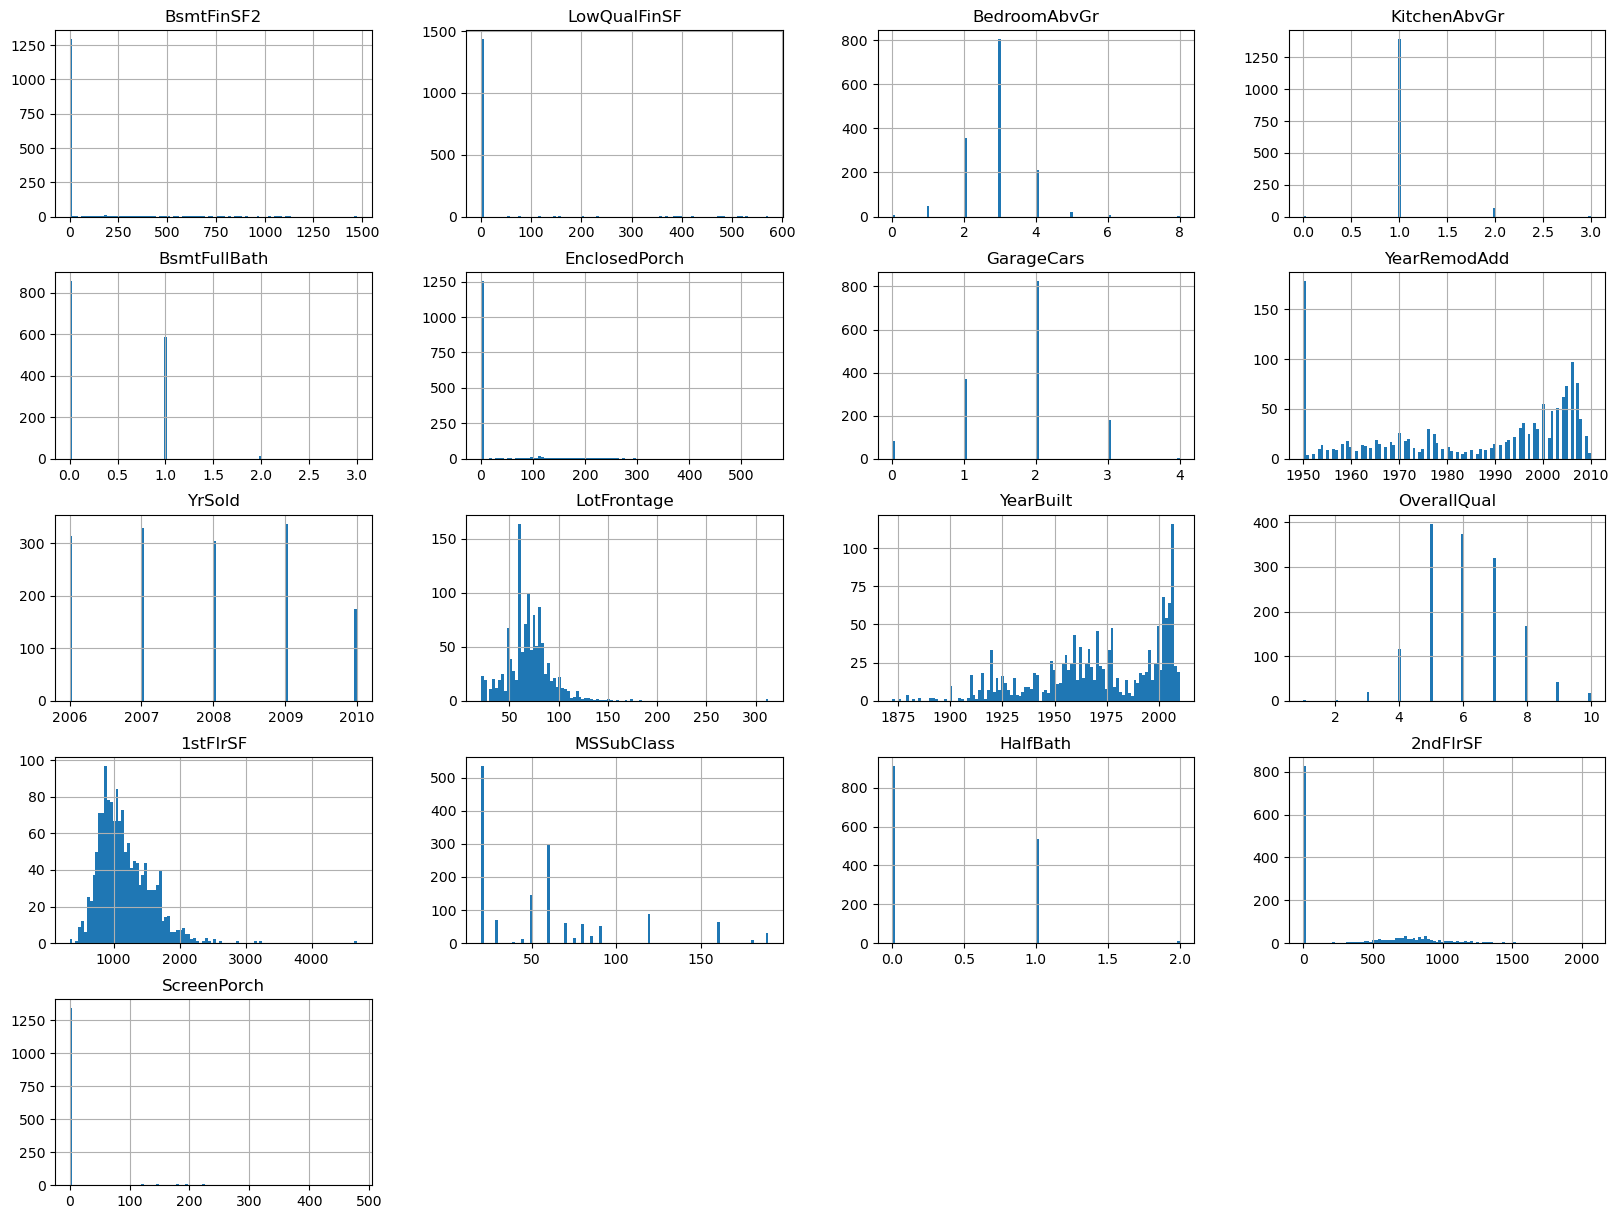

In [6]:
train_data[num_cols[20:]].hist(bins = 100, figsize = (20, 15))

In [7]:
corr_matrix = train_data[num_cols].corr()
corr_matrix

,TotRmsAbvGrd,FullBath,MasVnrArea,3SsnPorch,SalePrice,GarageYrBlt,MoSold,OverallCond,BsmtHalfBath,BsmtUnfSF,Fireplaces,PoolArea,TotalBsmtSF,WoodDeckSF,BsmtFinSF1,GarageArea,MiscVal,LotArea,GrLivArea,OpenPorchSF,BsmtFinSF2,LowQualFinSF,BedroomAbvGr,KitchenAbvGr,BsmtFullBath,EnclosedPorch,GarageCars,YearRemodAdd,YrSold,LotFrontage,YearBuilt,OverallQual,1stFlrSF,MSSubClass,HalfBath,2ndFlrSF,ScreenPorch
TotRmsAbvGrd,1.000000,0.554784,0.280682,-0.006683,0.533723,0.148112,0.036907,-0.057583,-0.023836,0.250647,0.326114,0.083757,0.285573,0.165984,0.044316,0.337822,0.024763,0.190015,0.825489,0.234192,-0.035227,0.131185,0.676620,0.256045,-0.053275,0.004151,0.362289,0.191740,-0.034516,0.352096,0.095589,0.427452,0.409516,0.040380,0.343415,0.616423,0.059383
FullBath,0.554784,1.000000,0.276833,0.035353,0.560664,0.484557,0.055872,-0.194149,-0.054536,0.288886,0.243671,0.049604,0.323722,0.187703,0.058543,0.405656,-0.014290,0.126031,0.630012,0.259977,-0.076444,-0.000710,0.363252,0.133115,-0.064512,-0.115093,0.469672,0.439046,-0.019669,0.198769,0.468271,0.550600,0.380637,0.131608,0.136381,0.421378,-0.008106
MasVnrArea,0.280682,0.276833,1.000000,0.018796,0.477493,0.252691,-0.005965,-0.128101,0.026673,0.114442,0.249070,0.011723,0.363936,0.159718,0.264736,0.373066,-0.029815,0.104160,0.390857,0.125703,-0.072319,-0.069071,0.102821,-0.037610,0.085310,-0.110204,0.364204,0.179618,-0.008201,0.193458,0.315707,0.411876,0.344501,0.022936,0.201444,0.174561,0.061466
3SsnPorch,-0.006683,0.035353,0.018796,1.000000,0.044584,0.023544,0.029474,0.025504,0.035114,0.020764,0.011257,-0.007992,0.037384,-0.032771,0.026451,0.035087,0.000354,0.020423,0.020643,-0.005842,-0.029993,-0.004296,-0.024478,-0.024600,-0.000106,-0.037305,0.035765,0.045286,0.018645,0.070029,0.031355,0.030371,0.056104,-0.043825,-0.004972,-0.024358,-0.031436
SalePrice,0.533723,0.560664,0.477493,0.044584,1.000000,0.486362,0.046432,-0.077856,-0.016844,0.214479,0.466929,0.092404,0.613581,0.324413,0.386420,0.623431,-0.021190,0.263843,0.708624,0.315856,-0.011378,-0.025606,0.168213,-0.135907,0.227122,-0.128578,0.640409,0.507101,-0.028923,0.351799,0.522897,0.790982,0.605852,-0.084284,0.284108,0.319334,0.111447
GarageYrBlt,0.148112,0.484557,0.252691,0.023544,0.486362,1.000000,0.005337,-0.324297,-0.077464,0.190708,0.046822,-0.014501,0.322445,0.224577,0.153484,0.564567,-0.032417,-0.024947,0.231197,0.228425,-0.088011,-0.036363,-0.064518,-0.124411,0.124553,-0.297003,0.588920,0.642277,-0.001014,0.070250,0.825667,0.547766,0.233449,0.085072,0.196785,0.070832,-0.075418
MoSold,0.036907,0.055872,-0.005965,0.029474,0.046432,0.005337,1.000000,-0.003511,0.032873,0.034888,0.046357,-0.033737,0.013196,0.021011,-0.015727,0.027974,-0.006495,0.001205,0.050240,0.071255,-0.015211,-0.022174,0.046544,0.026589,-0.025361,-0.028887,0.040522,0.021490,-0.145721,0.011200,0.012398,0.070815,0.031372,-0.013585,-0.009050,0.035164,0.023217
OverallCond,-0.057583,-0.194149,-0.128101,0.025504,-0.077856,-0.324297,-0.003511,1.000000,0.117821,-0.136841,-0.023820,-0.001985,-0.171098,-0.003334,-0.046231,-0.151521,0.068777,-0.005636,-0.079686,-0.032589,0.040229,0.025494,0.012980,-0.087001,-0.054942,0.070356,-0.185758,0.073741,0.043950,-0.059213,-0.375983,-0.091932,-0.144203,-0.059316,-0.060769,0.028942,0.054811
BsmtHalfBath,-0.023836,-0.054536,0.026673,0.035114,-0.016844,-0.077464,0.032873,0.117821,1.000000,-0.095804,0.028976,0.020025,-0.000315,0.040161,0.067418,-0.024536,-0.007367,0.048046,-0.018918,-0.025324,0.070948,-0.005842,0.046519,-0.037944,-0.147871,-0.008555,-0.020891,-0.012337,-0.046524,-0.007234,-0.038162,-0.040150,0.001956,-0.002333,-0.012340,-0.023855,0.032121
BsmtUnfSF,0.250647,0.288886,0.114442,0.020764,0.214479,0.190708,0.034888,-0.136841,-0.095804,1.000000,0.051575,-0.035092,0.415360,-0.005316,-0.495251,0.183303,-0.023837,-0.002618,0.240257,0.129005,-0.209294,0.028167,0.166643,0.030086,-0.422900,-0.002538,0.214175,0.181133,-0.041258,0.132644,0.149040,0.308159,0.317987,-0.140759,-0.041118,0.004469,-0.012579


<Axes: >

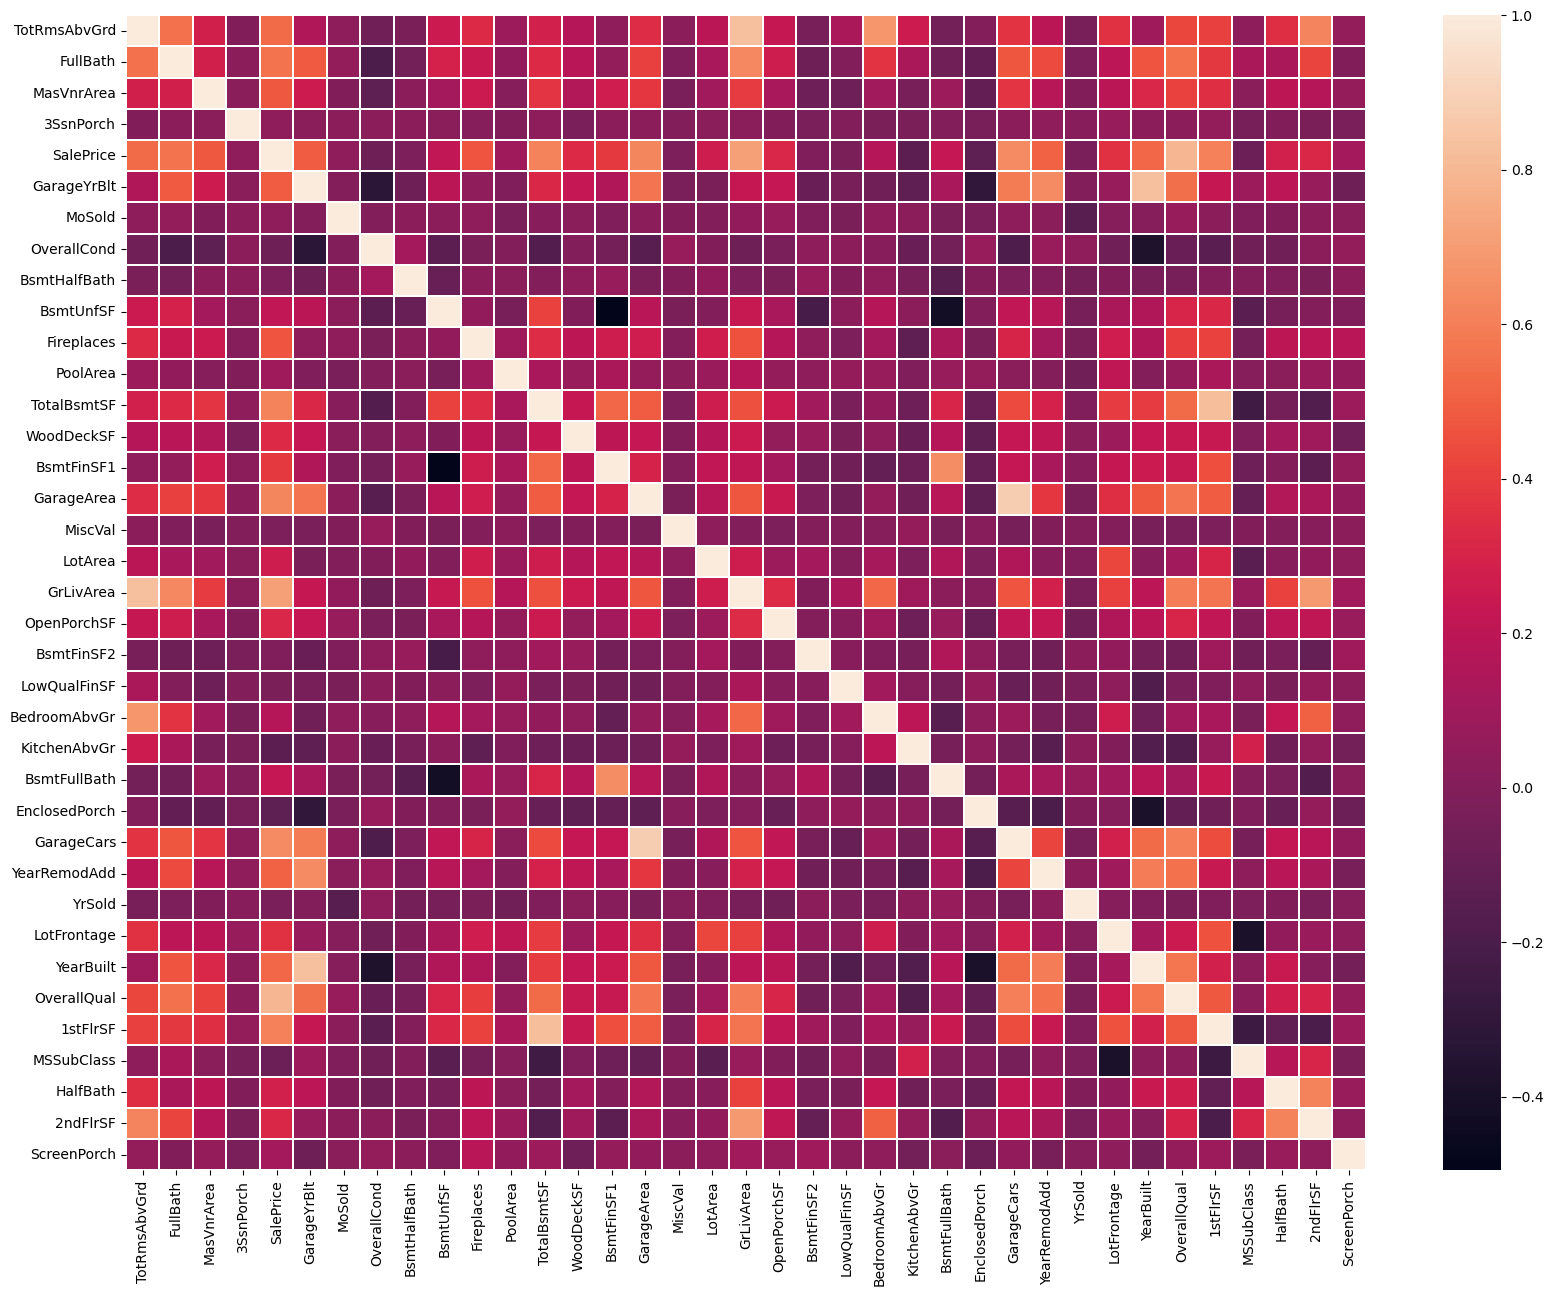

In [8]:
#heatmap
import seaborn as sns 
plt.subplots(figsize=(20,15))
sns.heatmap(corr_matrix,
           xticklabels = corr_matrix.columns.values,
           yticklabels = corr_matrix.columns.values,
           linewidth=0.1)

# Categorical Variables Visuals

In [9]:
df_list=[]
for cat_column in cat_cols:
    df_list.append(train_data.groupby([cat_column])['Id'].count().reset_index().rename(columns = {'Id' : 'count'}))
#     df_list.append(train_data[cat_column].value_counts().reset_index())


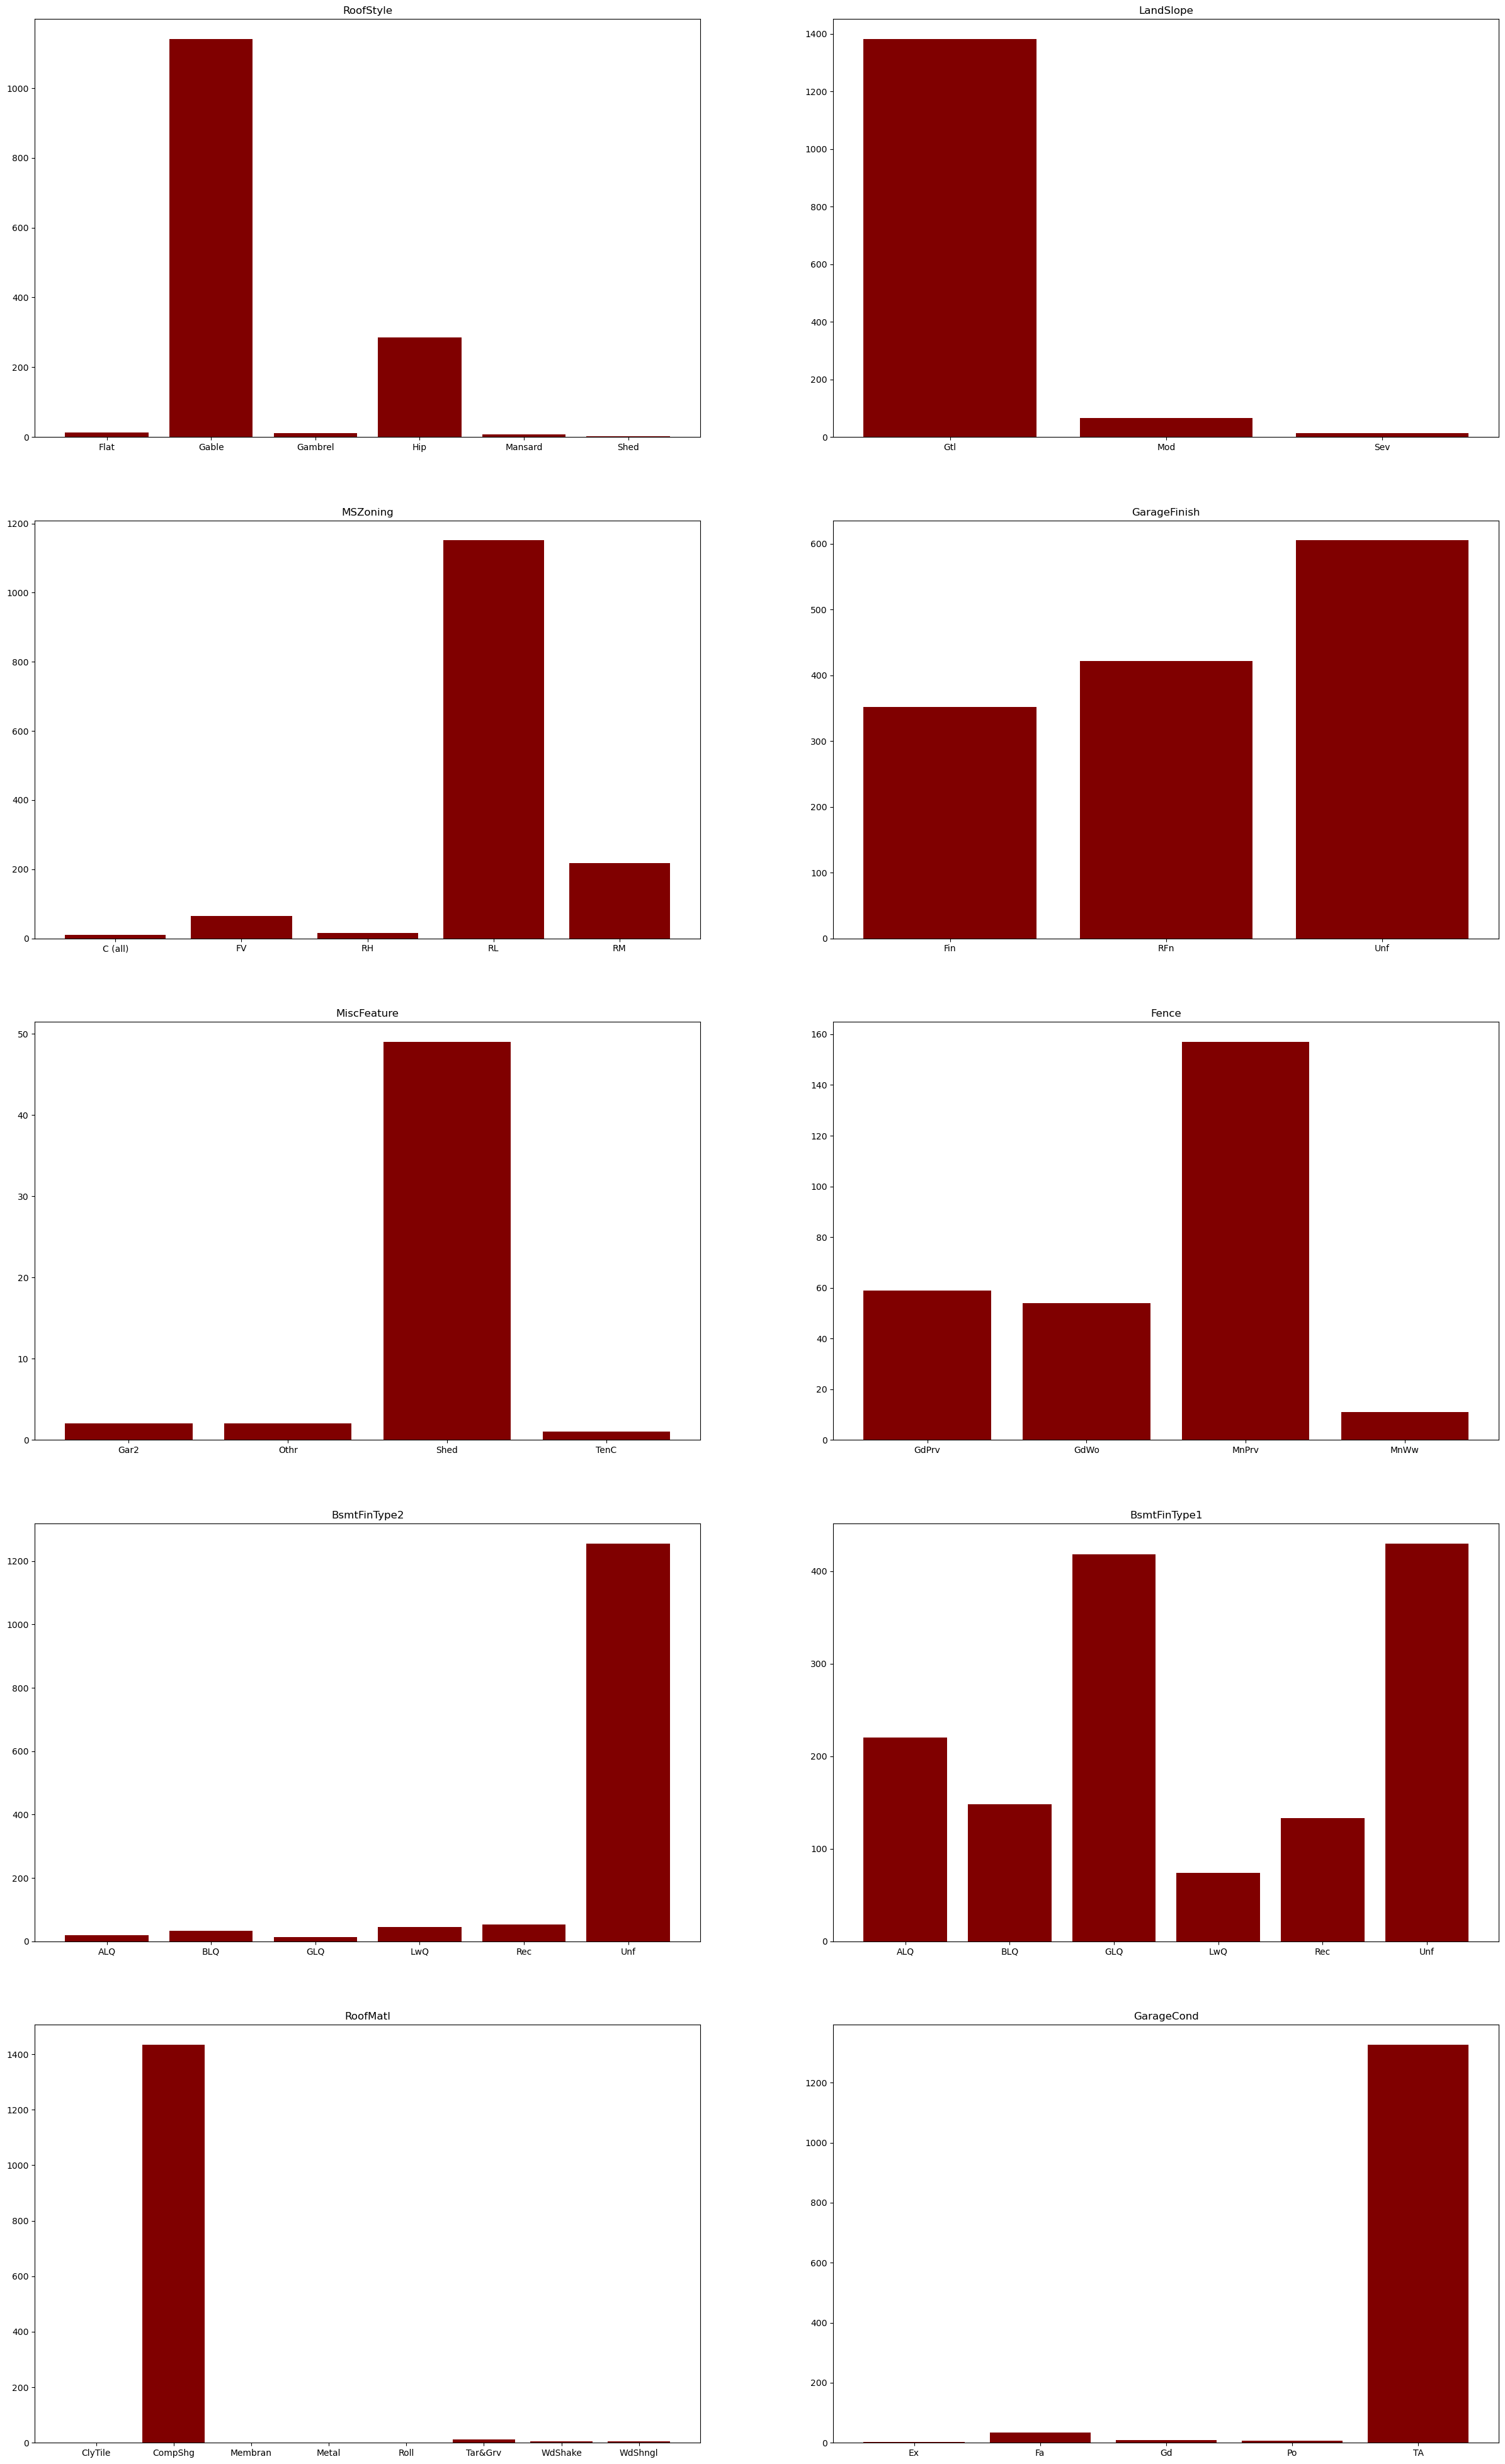

In [10]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[0:10]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

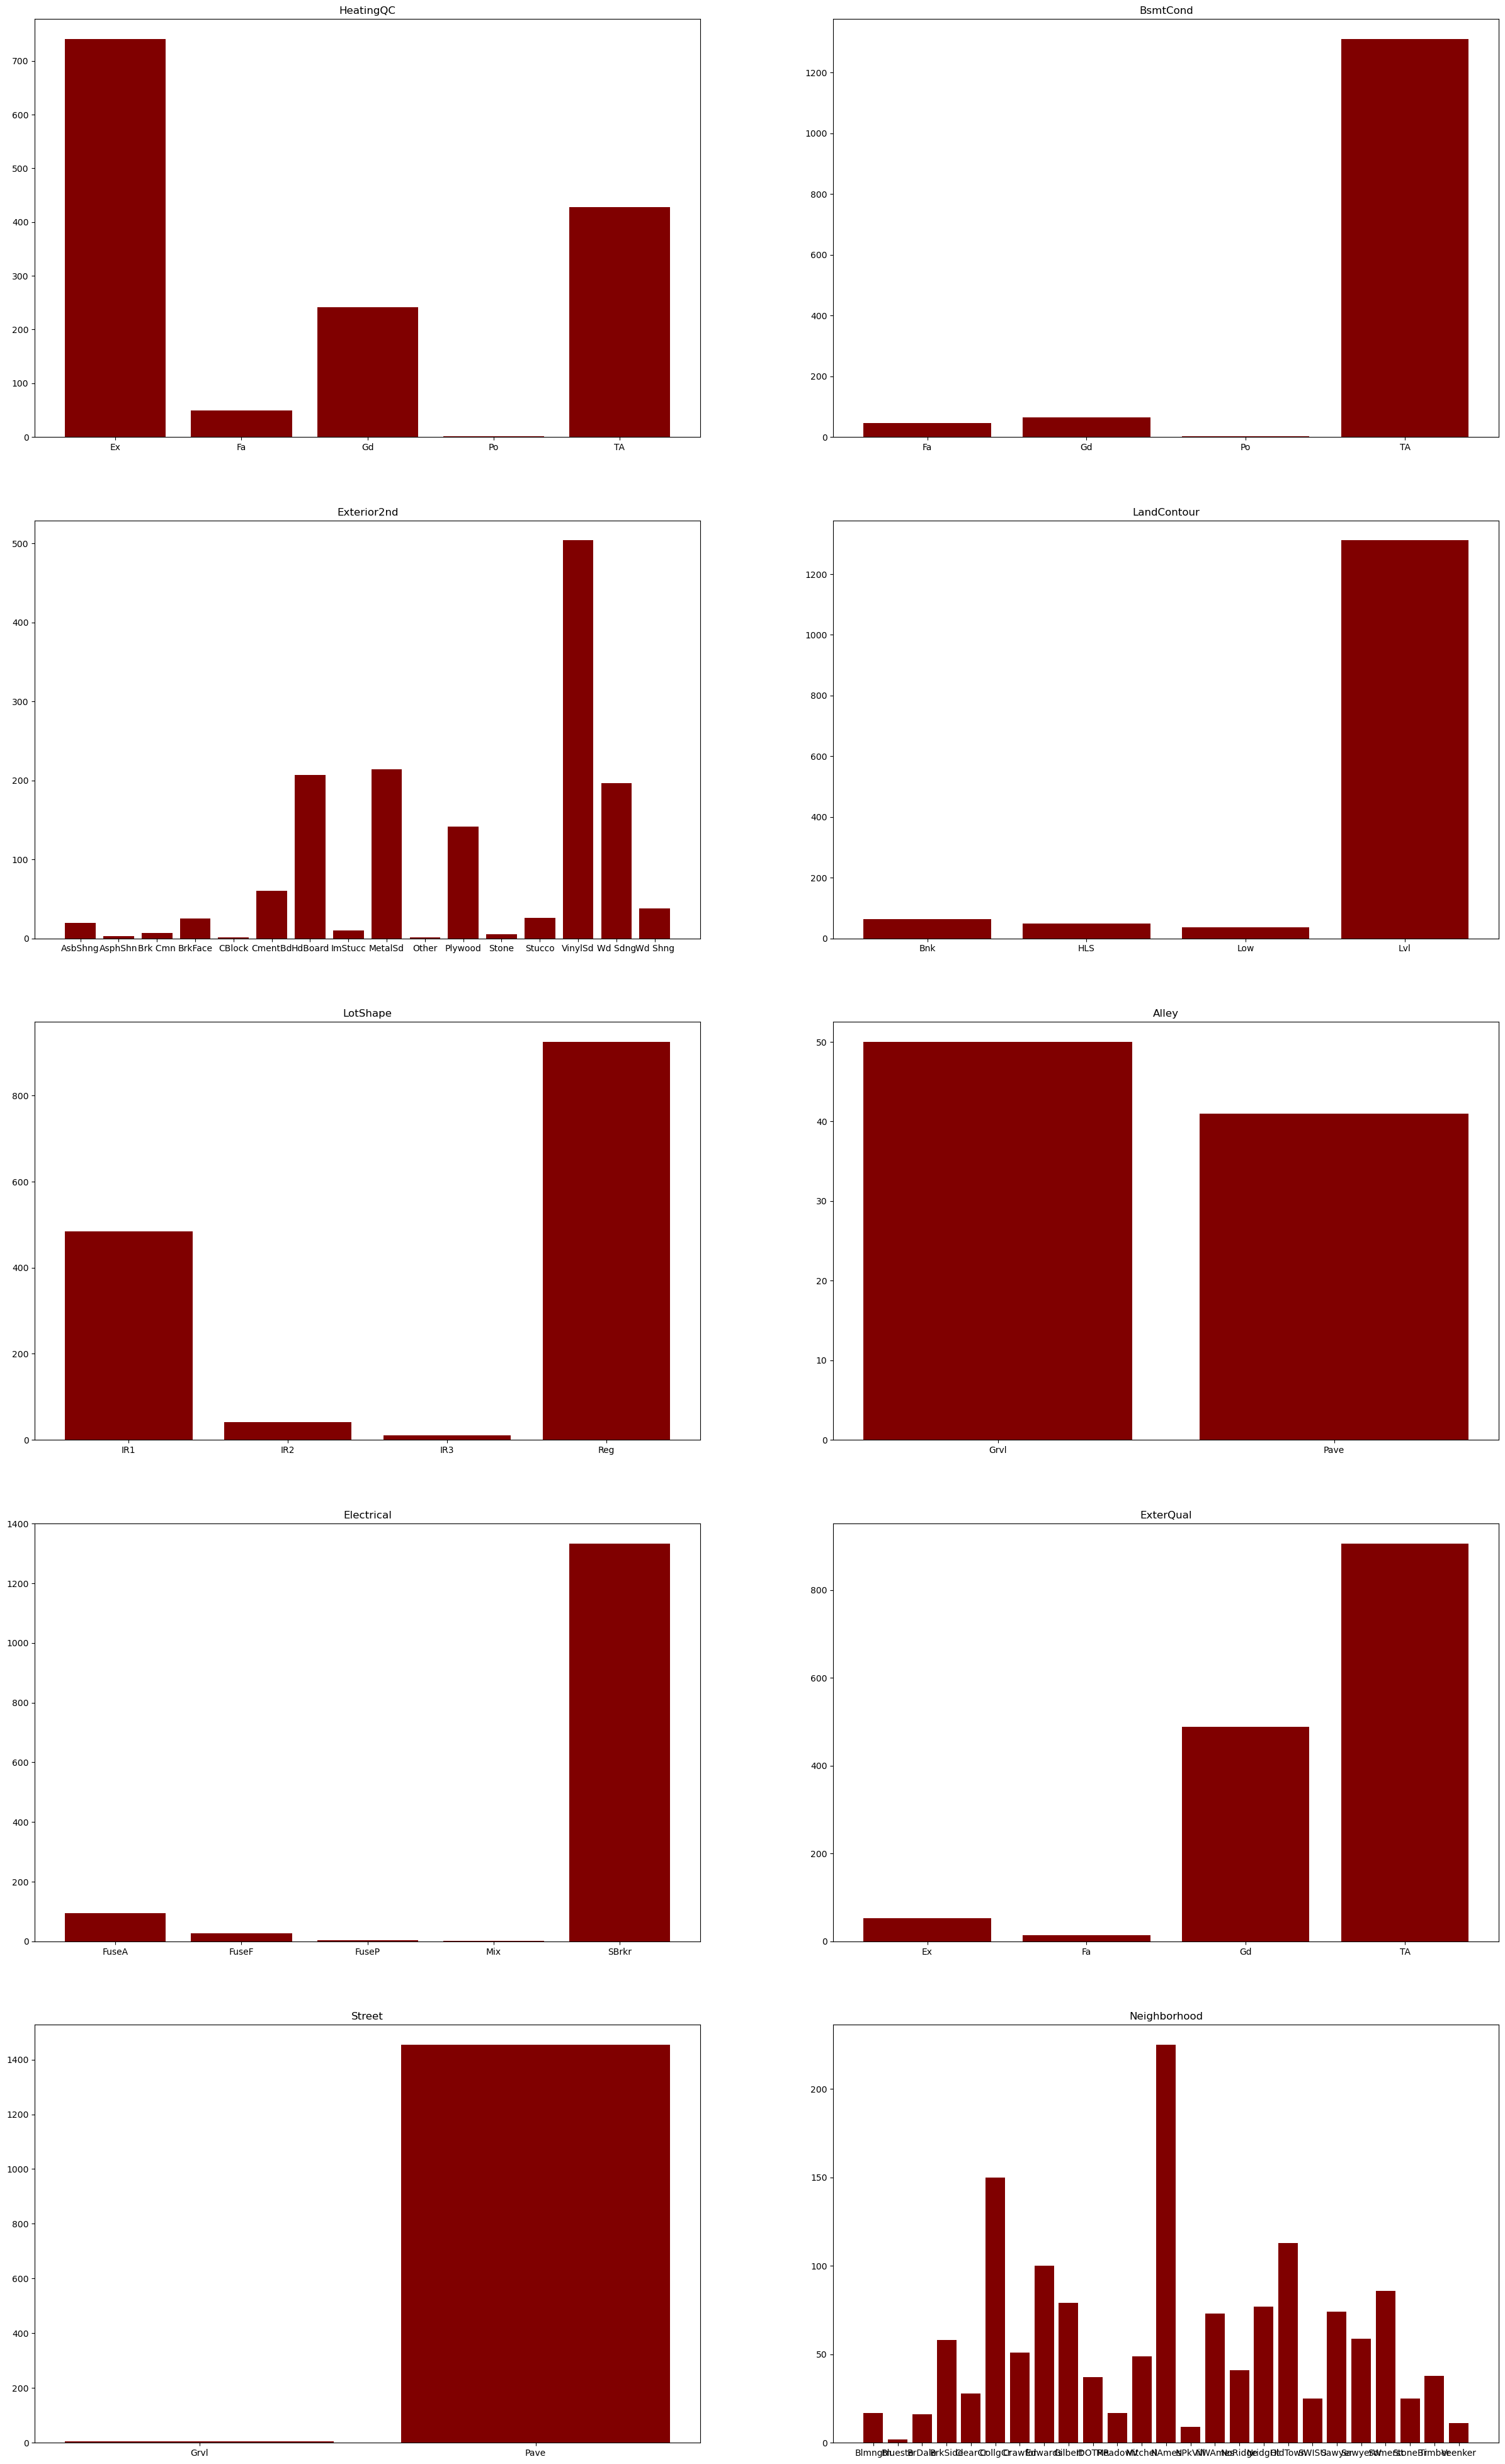

In [11]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[10:20]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

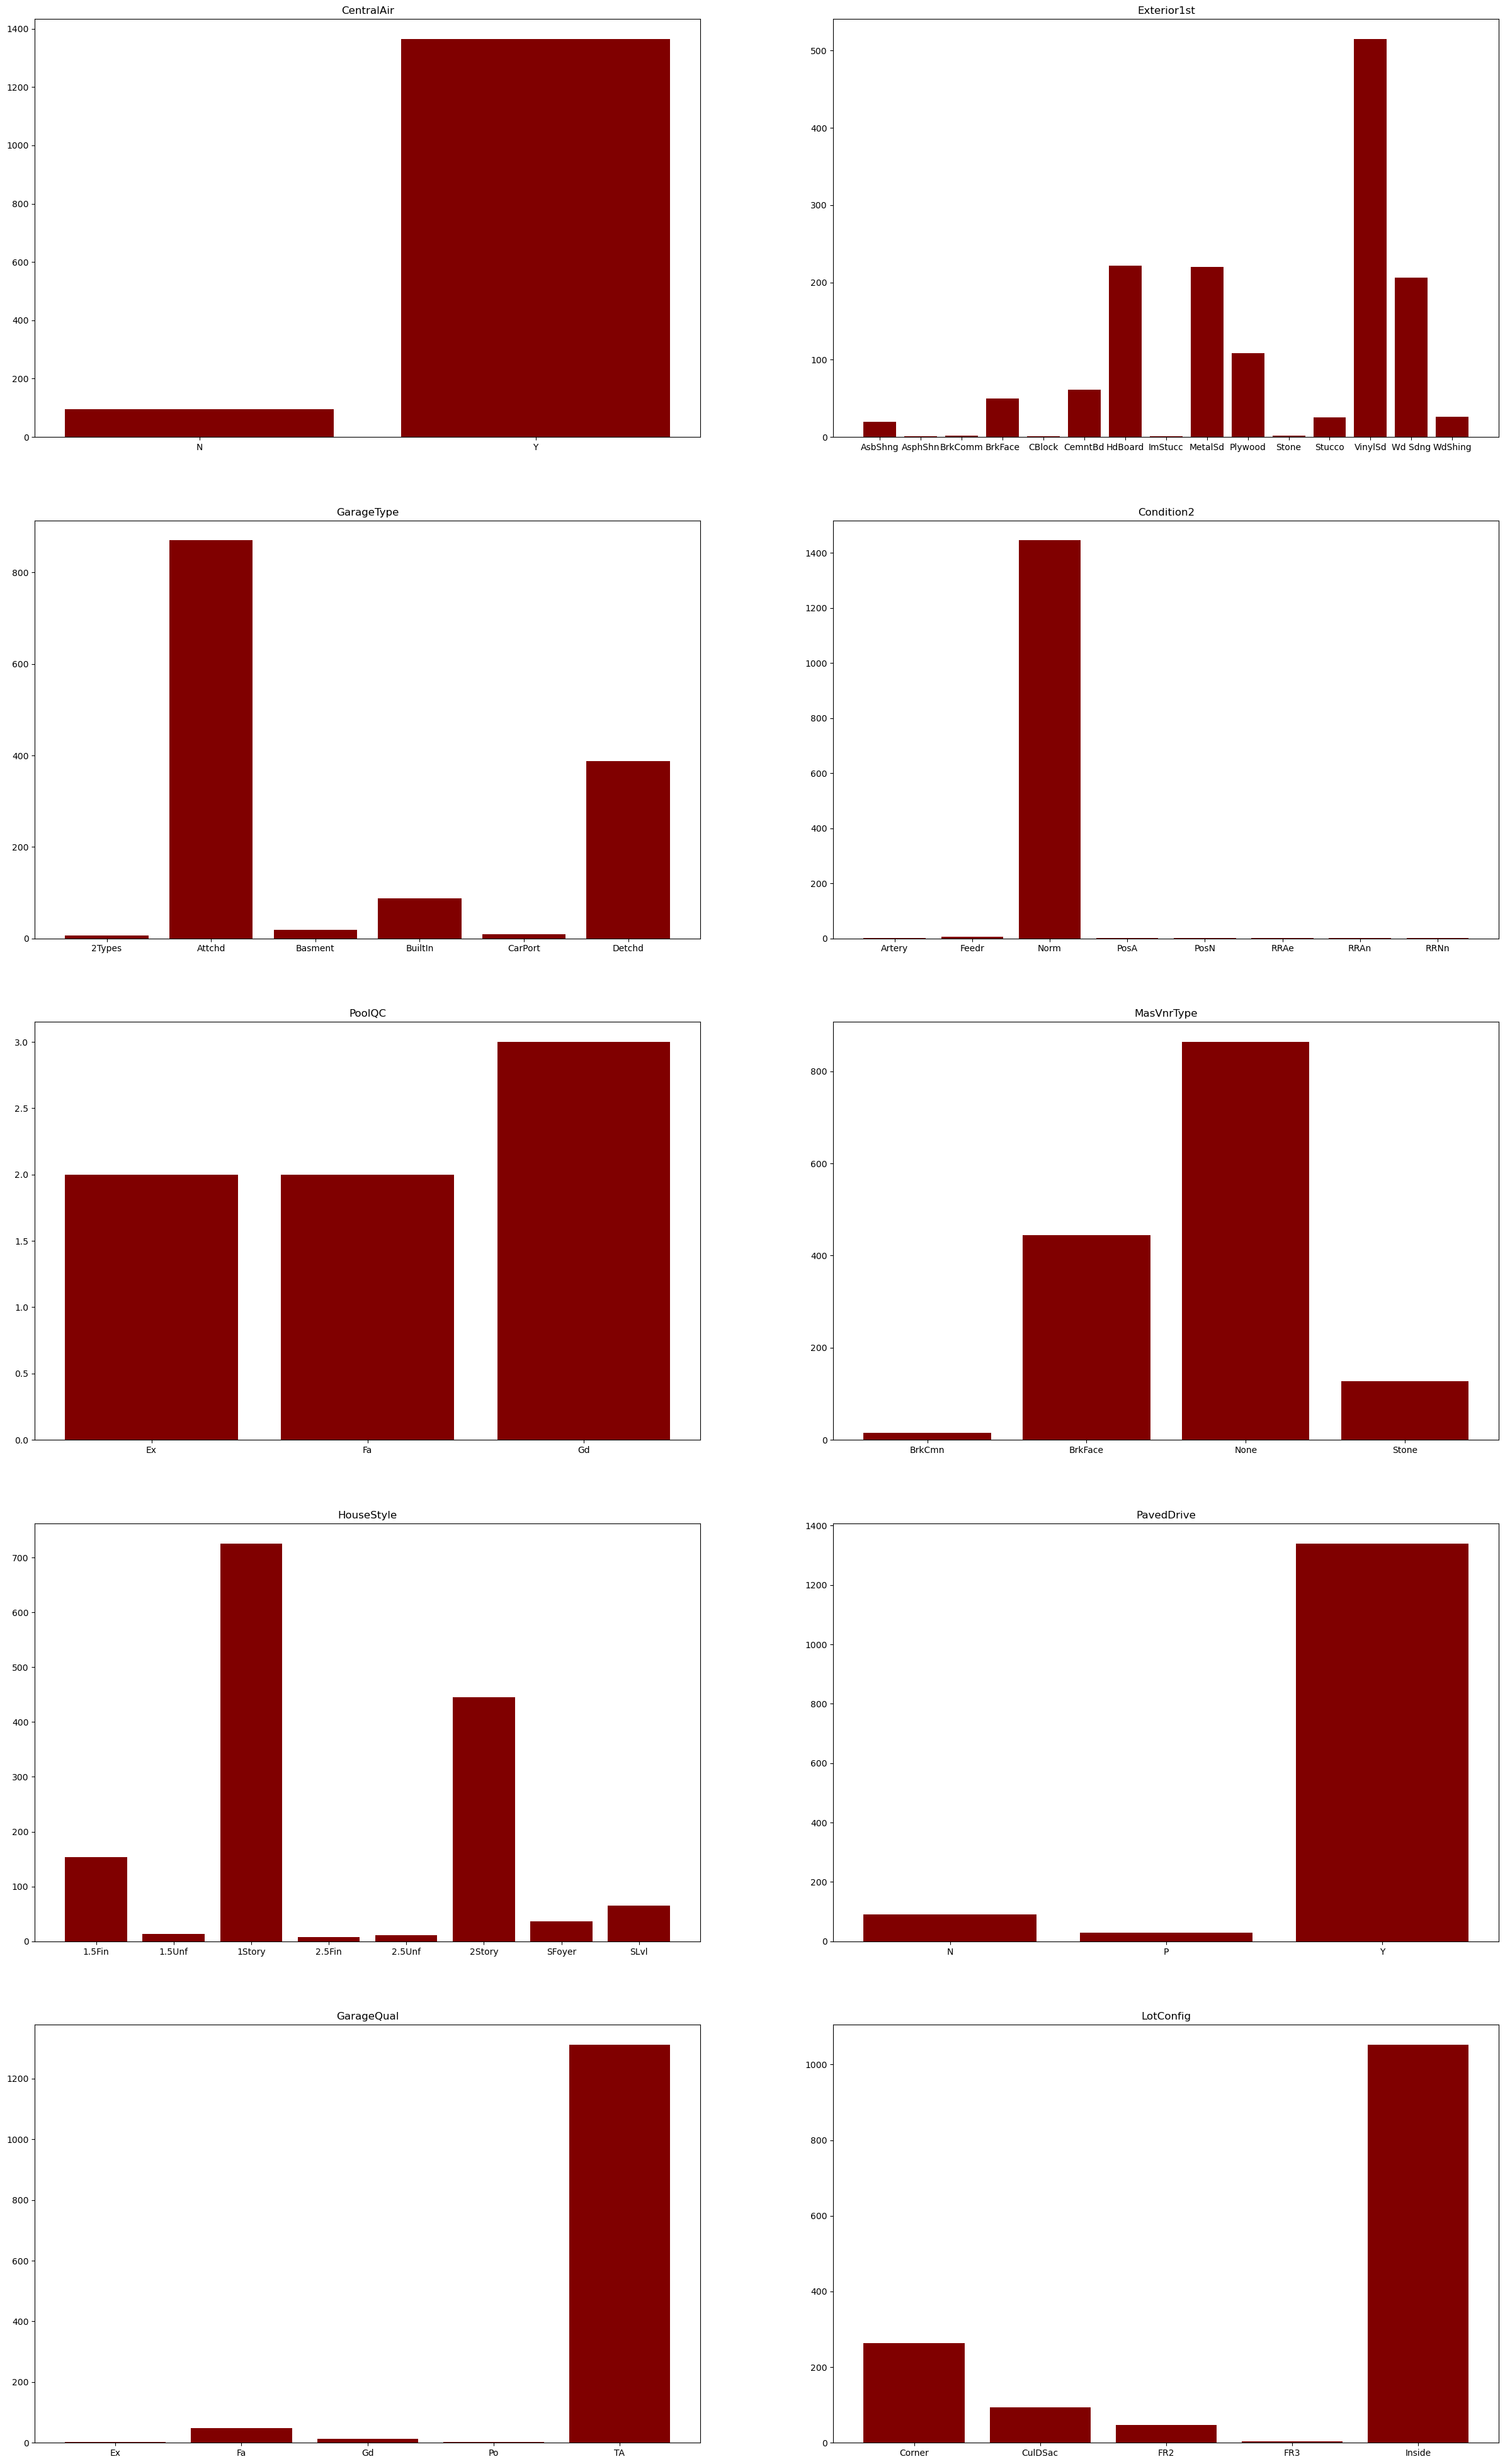

In [12]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[20:30]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

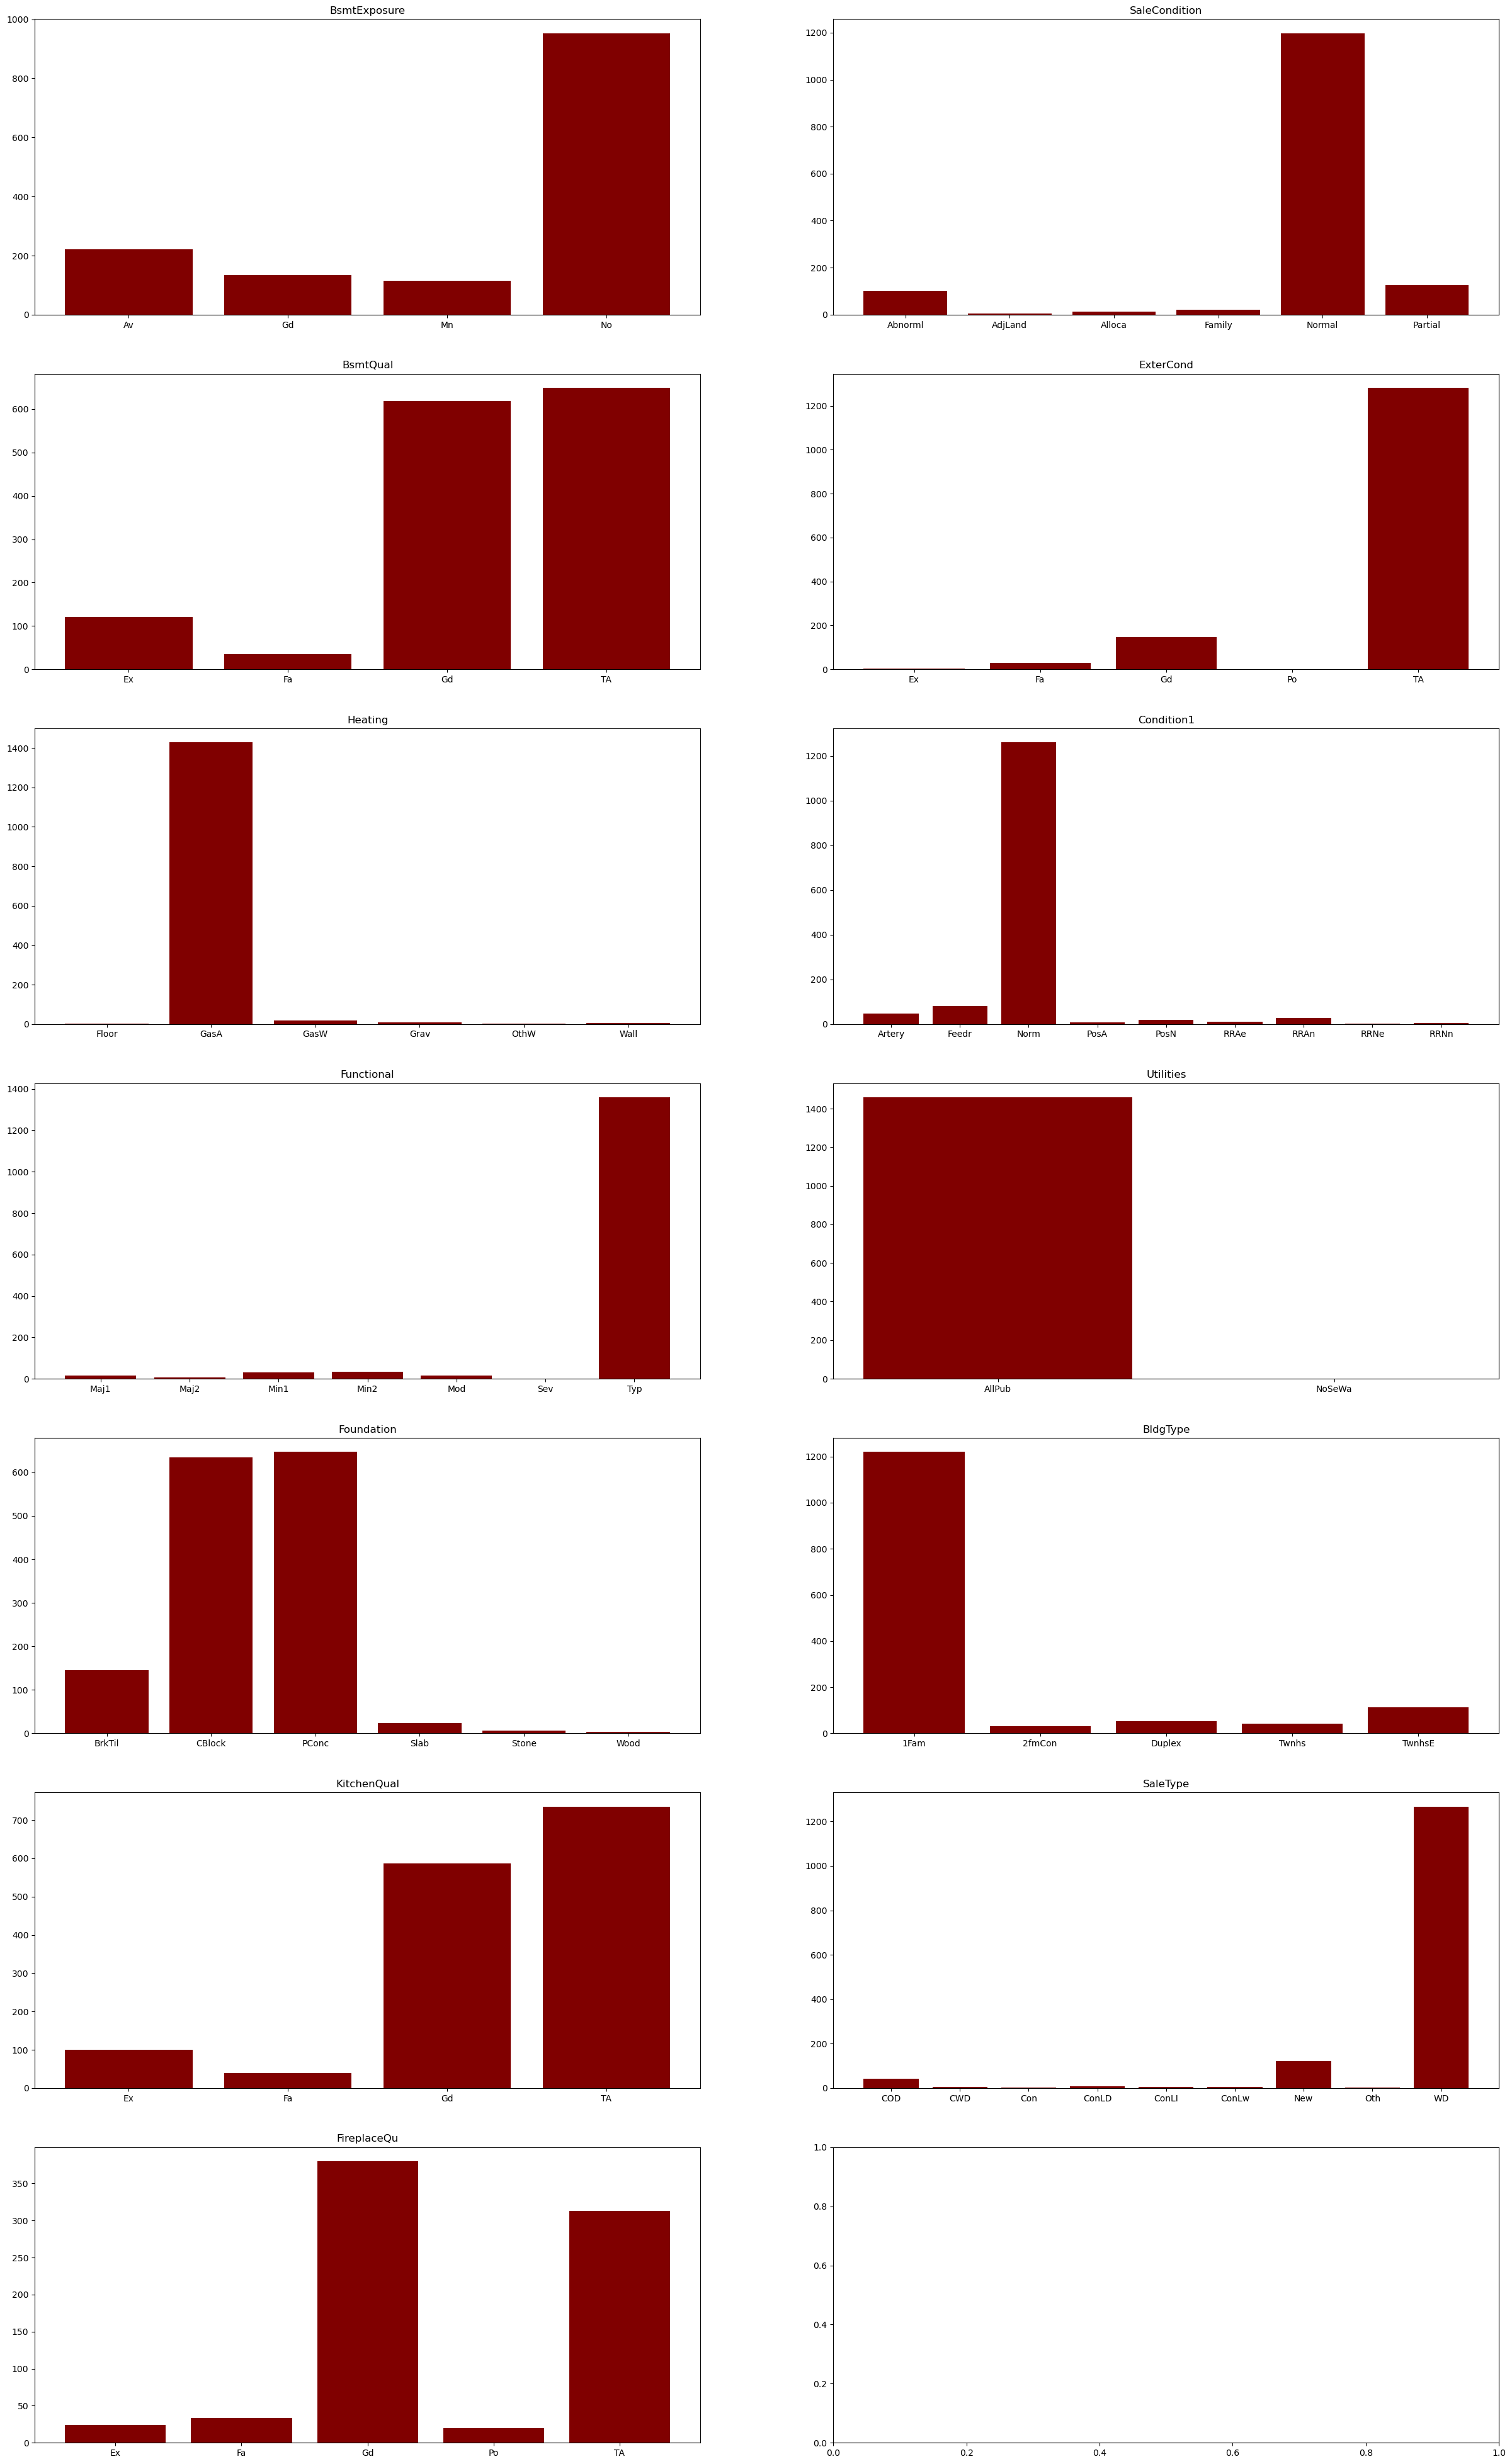

In [13]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(30, 50))
i=0
j=0
for df in df_list[30:]:
    axes[i, j].bar(df.iloc[:, 0],df.iloc[:, 1], color ='maroon')
    axes[i, j].set_title(df.columns[0])
    if(j<1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

# Preprocessing

## handling Null Values

In [14]:
train_data[num_cols].describe()

,TotRmsAbvGrd,FullBath,MasVnrArea,3SsnPorch,SalePrice,GarageYrBlt,MoSold,OverallCond,BsmtHalfBath,BsmtUnfSF,Fireplaces,PoolArea,TotalBsmtSF,WoodDeckSF,BsmtFinSF1,GarageArea,MiscVal,LotArea,GrLivArea,OpenPorchSF,BsmtFinSF2,LowQualFinSF,BedroomAbvGr,KitchenAbvGr,BsmtFullBath,EnclosedPorch,GarageCars,YearRemodAdd,YrSold,LotFrontage,YearBuilt,OverallQual,1stFlrSF,MSSubClass,HalfBath,2ndFlrSF,ScreenPorch
count,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.517808,1.565068,103.685262,3.409589,180921.195890,1978.506164,6.321918,5.575342,0.057534,567.240411,0.613014,2.758904,1057.429452,94.244521,443.639726,472.980137,43.489041,10516.828082,1515.463699,46.660274,46.549315,5.844521,2.866438,1.046575,0.425342,21.954110,1.767123,1984.865753,2007.815753,70.049958,1971.267808,6.099315,1162.626712,56.897260,0.382877,346.992466,15.060959
std,1.625393,0.550916,181.066207,29.317331,79442.502883,24.689725,2.703626,1.112799,0.238753,441.866955,0.644666,40.177307,438.705324,125.338794,456.098091,213.804841,496.123024,9981.264932,525.480383,66.256028,161.319273,48.623081,0.815778,0.220338,0.518911,61.119149,0.747315,20.645407,1.328095,24.284752,30.202904,1.382997,386.587738,42.300571,0.502885,436.528436,55.757415
min,2.000000,0.000000,0.000000,0.000000,34900.000000,1900.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1300.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1950.000000,2006.000000,21.000000,1872.000000,1.000000,334.000000,20.000000,0.000000,0.000000,0.000000
25%,5.000000,1.000000,0.000000,0.000000,129975.000000,1961.000000,5.000000,5.000000,0.000000,223.000000,0.000000,0.000000,795.750000,0.000000,0.000000,334.500000,0.000000,7553.500000,1129.500000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1967.000000,2007.000000,59.000000,1954.000000,5.000000,882.000000,20.000000,0.000000,0.000000,0.000000
50%,6.000000,2.000000,0.000000,0.000000,163000.000000,1980.000000,6.000000,5.000000,0.000000,477.500000,1.000000,0.000000,991.500000,0.000000,383.500000,480.000000,0.000000,9478.500000,1464.000000,25.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,2.000000,1994.000000,2008.000000,69.000000,1973.000000,6.000000,1087.000000,50.000000,0.000000,0.000000,0.000000
75%,7.000000,2.000000,166.000000,0.000000,214000.000000,2002.000000,8.000000,6.000000,0.000000,808.000000,1.000000,0.000000,1298.250000,168.000000,712.250000,576.000000,0.000000,11601.500000,1776.750000,68.000000,0.000000,0.000000,3.000000,1.000000,1.000000,0.000000,2.000000,2004.000000,2009.000000,80.000000,2000.000000,7.000000,1391.250000,70.000000,1.000000,728.000000,0.000000
max,14.000000,3.000000,1600.000000,508.000000,755000.000000,2010.000000,12.000000,9.000000,2.000000,2336.000000,3.000000,738.000000,6110.000000,857.000000,5644.000000,1418.000000,15500.000000,215245.000000,5642.000000,547.000000,1474.000000,572.000000,8.000000,3.000000,3.000000,552.000000,4.000000,2010.000000,2010.000000,313.000000,2010.000000,10.000000,4692.000000,190.000000,2.000000,2065.000000,480.000000


In [15]:
nulls_df = train_data.isna().sum().reset_index().rename(columns = {0:"Nulls_Count"})
nulls_df[nulls_df['Nulls_Count']> 0]

,index,Nulls_Count
3,LotFrontage,259
6,Alley,1369
25,MasVnrType,8
26,MasVnrArea,8
30,BsmtQual,37
31,BsmtCond,37
32,BsmtExposure,38
33,BsmtFinType1,37
35,BsmtFinType2,38
42,Electrical,1


In [16]:
#drop columns with 60% of data NULL
train_data = train_data.drop(columns=['Alley','PoolQC','Fence','MiscFeature','FireplaceQu'])

#drop small number of rows that have small number of null values using dropna
train_data = train_data.dropna(axis = 0, subset = ['GarageYrBlt', 'MasVnrArea', 'Electrical', 
                                                   'GarageFinish', 'GarageQual', 'GarageCond', 'GarageType',
                                                   'BsmtFinType2', 'BsmtFinType1', 'BsmtExposure', 'BsmtCond', 
                                                   'BsmtQual', 'MasVnrType'])
# fill nulls with the mean 
train_data['LotFrontage']=train_data['LotFrontage'].fillna(train_data['LotFrontage'].mean())

In [17]:
nulls_df = train_data.isna().sum().reset_index().rename(columns = { 0 : "Nulls_Count"})
nulls_df[nulls_df['Nulls_Count'] > 0]

,index,Nulls_Count


### Dropping any column which has 80% of values with the same value 

In [18]:
def dropping_var_with_same_value(count_df,df):
    highest_freq_percentage = (count_df['count']/df.count()[0]).\
                    reset_index().sort_values(by=['count'],ascending=
                    False).iloc[0,1]
    if highest_freq_percentage>= 0.8:
        print('we will drop the column ',count_df.columns[0])
        df = df.drop(columns = [count_df.columns[0]])
    return df

In [19]:
for idx in range(len(df_list)):
  train_data = dropping_var_with_same_value(df_list[idx], train_data)

we will drop the column  RoofStyle
we will drop the column  LandSlope
we will drop the column  MSZoning
we will drop the column  BsmtFinType2
we will drop the column  RoofMatl
we will drop the column  GarageCond
we will drop the column  BsmtCond
we will drop the column  LandContour
we will drop the column  Electrical
we will drop the column  Street
we will drop the column  CentralAir
we will drop the column  Condition2
we will drop the column  PavedDrive
we will drop the column  GarageQual
we will drop the column  SaleCondition
we will drop the column  ExterCond
we will drop the column  Heating
we will drop the column  Condition1
we will drop the column  Functional
we will drop the column  Utilities
we will drop the column  BldgType
we will drop the column  SaleType


### If we have 2 highly correlated features (corr > 0.7), we drop one of them (the variable which is less correlated to the response variable)

In [20]:
num_cols = list(set(train_data.describe().columns.to_list()) - set(["Id"]))
cat_cols = list(set(train_data.columns.to_list())-set(num_cols)-set(["Id"]))

In [21]:
num_cols_without_response_variable = list(set(num_cols) - set(['SalePrice']))
corr_matrix = train_data[num_cols_without_response_variable].corr()
corr_matrix

,TotRmsAbvGrd,FullBath,MasVnrArea,3SsnPorch,GarageYrBlt,MoSold,OverallCond,BsmtHalfBath,BsmtUnfSF,Fireplaces,PoolArea,WoodDeckSF,BsmtFinSF1,GarageArea,MiscVal,MSSubClass,LotArea,GrLivArea,OpenPorchSF,BsmtFinSF2,LowQualFinSF,BedroomAbvGr,KitchenAbvGr,BsmtFullBath,EnclosedPorch,GarageCars,YearRemodAdd,YrSold,LotFrontage,YearBuilt,OverallQual,1stFlrSF,TotalBsmtSF,HalfBath,2ndFlrSF,ScreenPorch
TotRmsAbvGrd,1.000000,0.547592,0.289758,-0.011026,0.148625,0.041562,-0.063883,-0.016705,0.242020,0.332325,0.088279,0.166052,0.046284,0.368435,0.026111,0.014514,0.185654,0.823491,0.249396,-0.042207,0.092241,0.658923,0.234984,-0.052065,-0.003321,0.404416,0.174660,-0.046446,0.320599,0.099415,0.442941,0.393786,0.297609,0.357991,0.619275,0.058056
FullBath,0.547592,1.000000,0.272271,0.039987,0.486013,0.058436,-0.211882,-0.065641,0.305802,0.238053,0.050780,0.189532,0.045094,0.424693,-0.018492,0.117720,0.115727,0.625953,0.284951,-0.090448,-0.023550,0.355542,0.078037,-0.084267,-0.130885,0.512502,0.460120,-0.025019,0.172341,0.486777,0.580425,0.367498,0.345685,0.134953,0.419523,-0.013938
MasVnrArea,0.289758,0.272271,1.000000,0.015221,0.249750,-0.013461,-0.141080,0.015804,0.104662,0.229365,0.009334,0.149182,0.253015,0.367237,-0.028975,0.031333,0.096727,0.392006,0.129015,-0.083303,-0.061707,0.108829,-0.007299,0.078875,-0.112225,0.363916,0.168311,-0.001521,0.176261,0.299410,0.401175,0.341001,0.365629,0.193268,0.169730,0.052474
3SsnPorch,-0.011026,0.039987,0.015221,1.000000,0.027562,0.031341,0.023789,0.036301,0.023701,0.002661,-0.008518,-0.039635,0.026811,0.029688,0.000877,-0.041391,0.019326,0.018512,-0.005128,-0.031475,-0.000059,-0.027718,-0.020318,0.000482,-0.036712,0.030462,0.039422,0.023326,0.064765,0.028982,0.026470,0.053159,0.043142,-0.006568,-0.024786,-0.033613
GarageYrBlt,0.148625,0.486013,0.249750,0.027562,1.000000,0.002463,-0.336541,-0.079362,0.180539,0.039871,-0.014934,0.224075,0.144611,0.563860,-0.031451,0.082040,-0.025700,0.224903,0.220879,-0.092595,-0.037214,-0.071565,-0.125614,0.115751,-0.303525,0.590301,0.641585,-0.002948,0.063657,0.825172,0.545835,0.237928,0.321500,0.187518,0.060414,-0.077428
MoSold,0.041562,0.058436,-0.013461,0.031341,0.002463,1.000000,-0.011772,0.026507,0.031202,0.055795,-0.035568,0.031197,-0.021242,0.016794,-0.008498,-0.016283,0.000118,0.051474,0.060913,-0.022039,-0.027212,0.049966,0.036045,-0.022993,-0.022169,0.032796,0.014552,-0.144862,0.013494,0.004396,0.062641,0.024109,0.000787,-0.010915,0.042201,0.023331
OverallCond,-0.063883,-0.211882,-0.141080,0.023789,-0.336541,-0.011772,1.000000,0.119671,-0.161038,-0.031910,-0.003544,-0.012947,-0.060068,-0.204905,0.077314,-0.098153,0.001415,-0.093843,-0.060429,0.035698,0.041865,0.023180,-0.070910,-0.070089,0.071473,-0.249832,0.035076,0.056340,-0.042155,-0.417330,-0.163080,-0.144066,-0.228020,-0.073568,0.011685,0.053759
BsmtHalfBath,-0.016705,-0.065641,0.015804,0.036301,-0.079362,0.026507,0.119671,1.000000,-0.105359,0.026147,0.019777,0.039305,0.057227,-0.044979,-0.006685,-0.000151,0.046420,-0.020012,-0.034818,0.072813,0.003802,0.047645,0.010247,-0.159263,-0.003071,-0.041899,-0.023966,-0.042466,-0.000432,-0.055204,-0.064952,-0.000064,-0.019716,-0.016143,-0.023955,0.029737
BsmtUnfSF,0.242020,0.305802,0.104662,0.023701,0.180539,0.031202,-0.161038,-0.105359,1.000000,0.033157,-0.039315,-0.020711,-0.552809,0.195401,-0.018566,-0.141025,-0.014589,0.222438,0.122171,-0.233449,-0.002384,0.154935,0.081795,-0.463986,-0.003372,0.242278,0.171881,-0.039076,0.102041,0.147762,0.292940,0.318097,0.363767,-0.074157,-0.016117,-0.023065
Fireplaces,0.332325,0.238053,0.229365,0.002661,0.039871,0.055795,-0.031910,0.026147,0.033157,1.000000,0.095253,0.183778,0.245323,0.203763,0.005279,-0.024752,0.263061,0.458109,0.171643,0.035643,0.001746,0.117012,-0.092535,0.133045,-0.021637,0.245895,0.089952,-0.018577,0.230870,0.110807,0.377359,0.401929,0.328103,0.191549,0.188514,0.177515


In [22]:
for row_idx in range(corr_matrix.values.shape[0]):
    for col_idx in range(row_idx+1,corr_matrix.values.shape[0]):
        if (np.abs(corr_matrix.values[row_idx,col_idx])>0.7):
            var_row_corr_with_response = np.abs(np.corrcoef(train_data['SalePrice'],
                                                           train_data[num_cols_without_response_variable[row_idx]])[0,1])
            var_col_corr_with_response = np.abs(np.corrcoef(train_data['SalePrice'],
                                                           train_data[num_cols_without_response_variable[col_idx]])[0,1])
            if var_row_corr_with_response > var_col_corr_with_response:
                print('drop the column: ',num_cols_without_response_variable[col_idx])
                train_data = train_data.drop(columns=[num_cols_without_response_variable[col_idx]])
            else:
                print('drop the column: ',num_cols_without_response_variable[row_idx])
                train_data = train_data.drop(columns=[num_cols_without_response_variable[row_idx]])
                

drop the column:  TotRmsAbvGrd
drop the column:  GarageYrBlt
drop the column:  GarageArea
drop the column:  TotalBsmtSF


In [23]:
num_cols = list(set(train_data.describe().columns.to_list())-set('Id'))
cat_cols = list(set(train_data.columns.to_list())-set(num_cols)-set(['Id']))

In [24]:
len(num_cols)

34

## Clip Outliers

In [25]:
def clip_outliers(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Upper_Bound = Q3 + 1.5 * IQR
    Lower_Bound = Q1 - 1.5 * IQR
    
    df[col] = df[col].clip(lower=Lower_Bound, upper=Upper_Bound)
    
    return df

actual_num_cols = [col for col in num_cols if col in train_data.columns]

for col in actual_num_cols:
    train_data = clip_outliers(train_data, col)
print("Done clamping outliers successfully!")

Done clamping outliers successfully!


In [26]:
num_cols = list(set(train_data.describe().columns.to_list())-set('Id'))
cat_cols = list(set(train_data.columns.to_list())-set(num_cols)-set(['Id']))

## log-transform any highly skewed variable

In [27]:
for col in num_cols:
    sk = train_data[col].skew()
    if sk >= 1 or sk <= -1:
        
        train_data[col] = np.where(train_data[col] >= 0, 
                                   np.log1p(train_data[col]), 
                                   train_data[col])

## checking if the variable follows normal distribution 

In [30]:
num_cols = list(set(train_data.describe().columns.to_list())- set(["Id"]))
cat_cols = list(set(train_data.columns.to_list()) - set(num_cols) - set(["Id"]))
len(num_cols)

33

### QQPlot

IndexError: index 7 is out of bounds for axis 0 with size 7

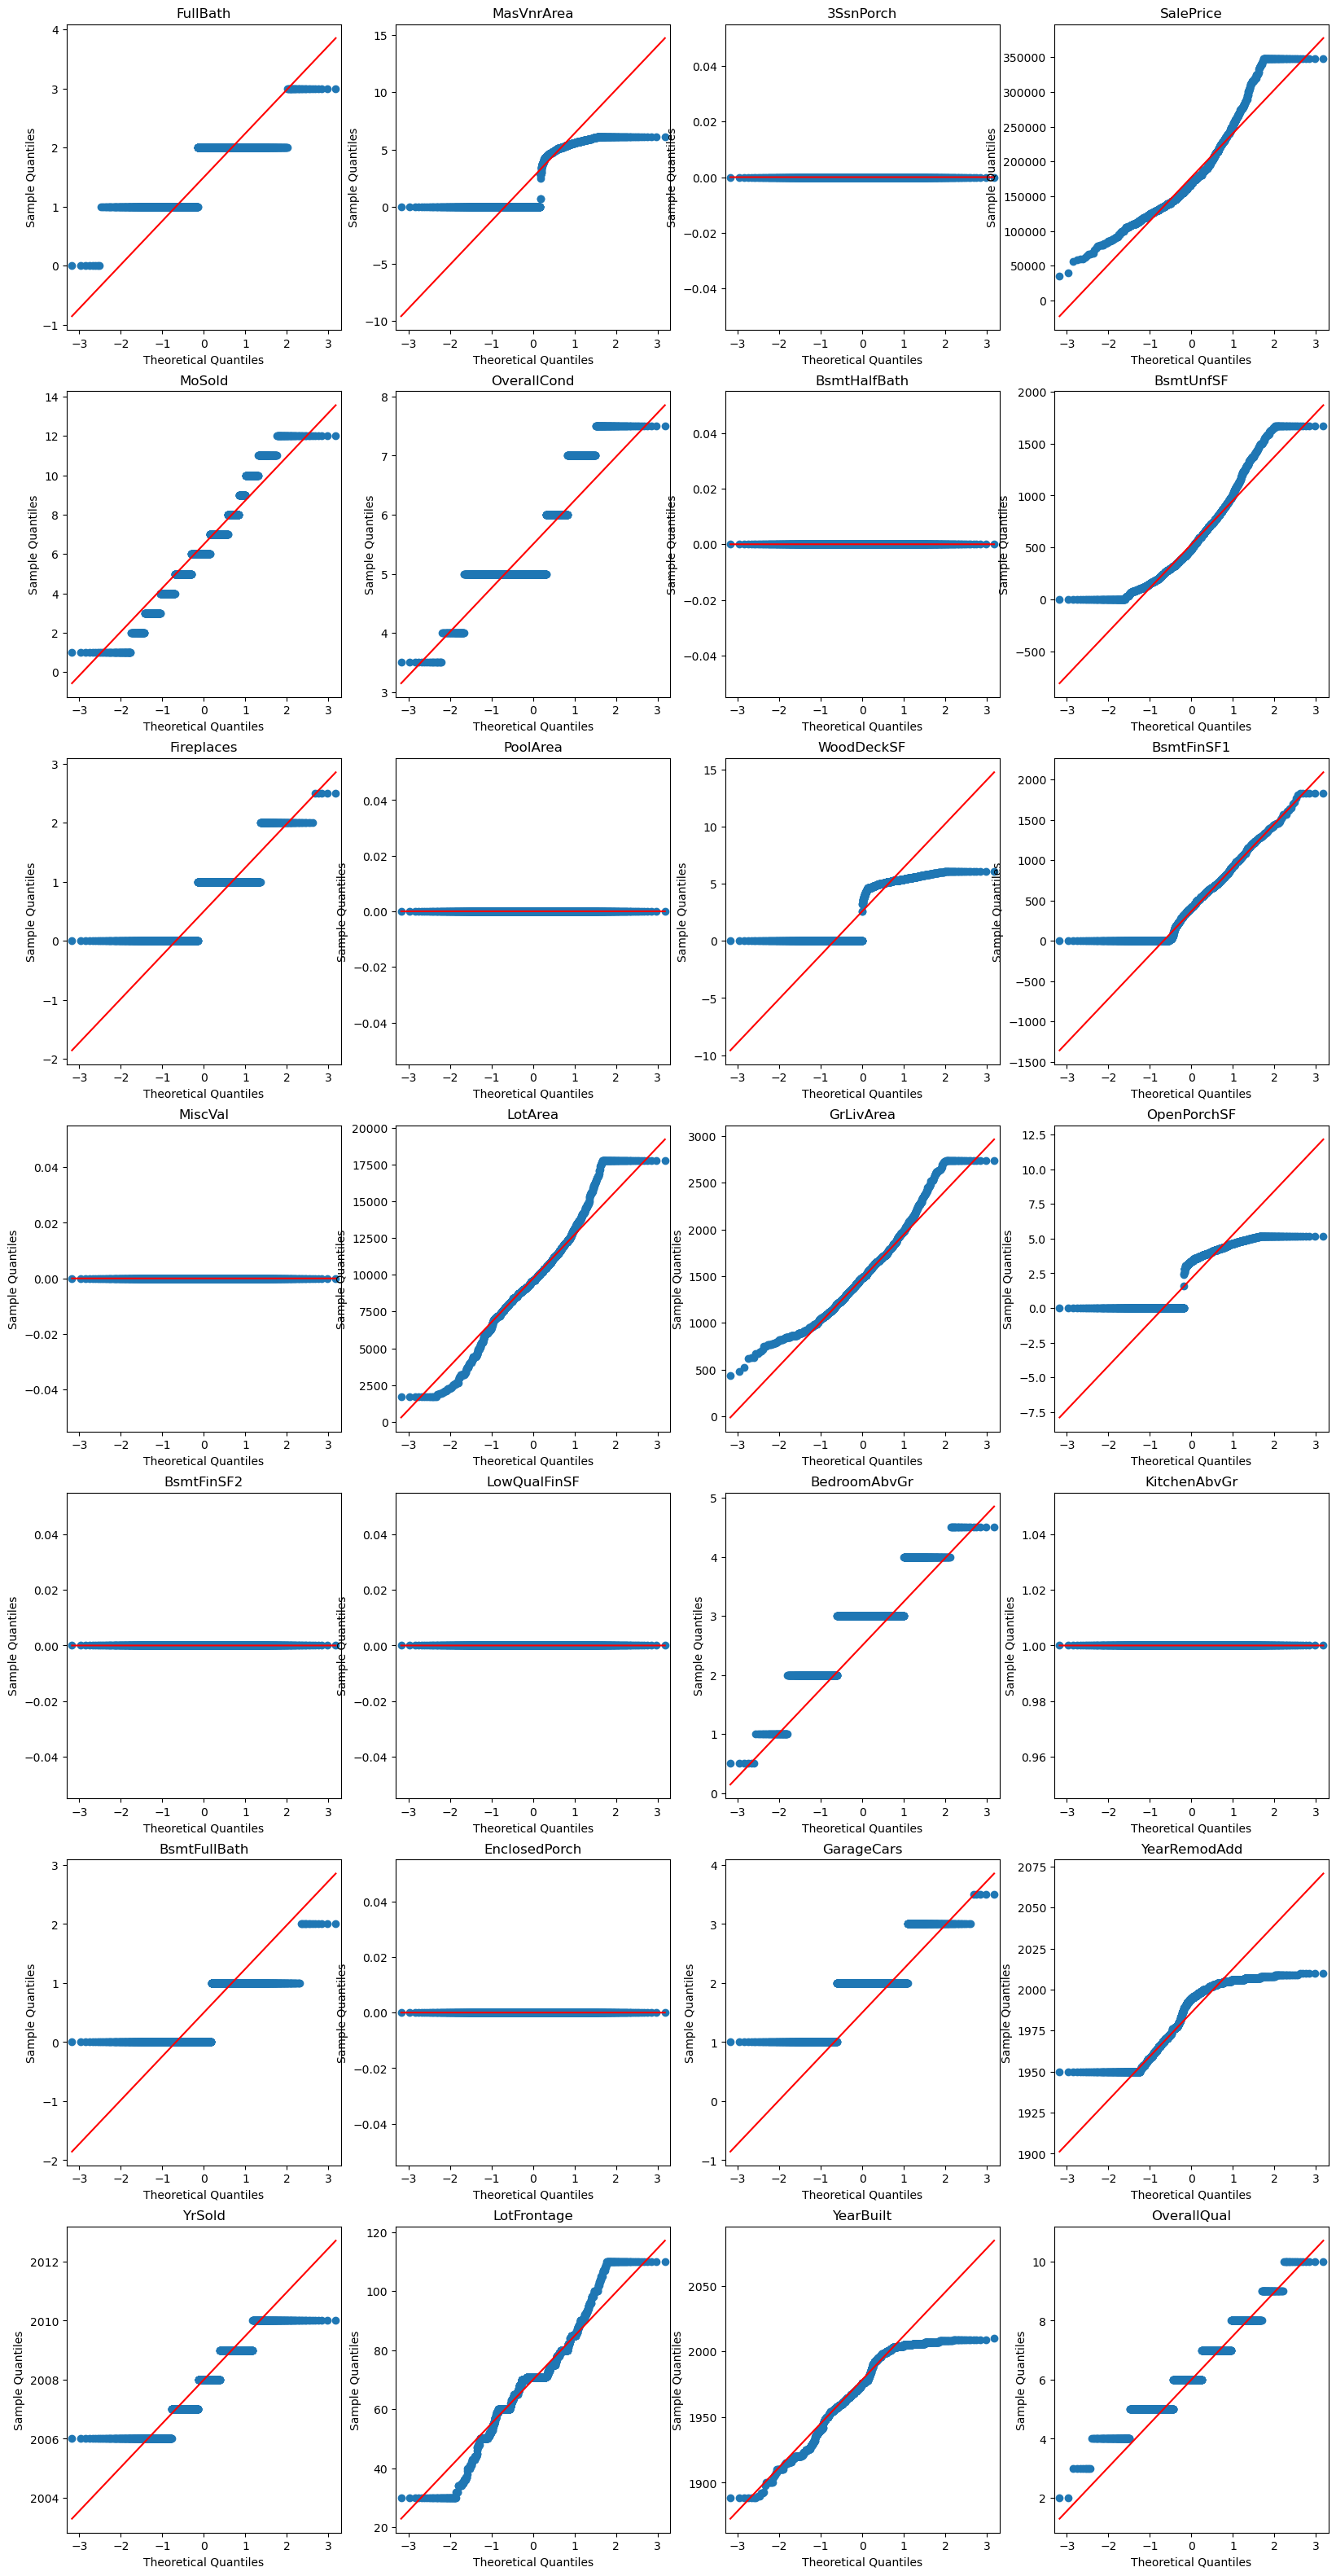

In [35]:
import statsmodels.api as sm
nrows=7
ncols=4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20,40))
i=0
j=0
for col in num_cols:
    sm.qqplot(train_data[col],fit=False,line='q',ax=axes[i,j])
    axes[i,j].set_title(col)
    if (j<ncols-1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

### Shapiro-Wilk test

In [36]:
""" Testing the normally distributed features using Shapiro-Wilk test
 the null hypothesis here is that the data follows a normal distribution
 we reject the null hypothesis (aka: data is not normally distributed) if the p-value is less than alpha (typically 5%)
 and we fail to reject the null hypothesis (aka: data is normally distributes) if the p-value is greater than alpha """
feats_std_scale = []
feats_min_max_scale = []
from scipy.stats import shapiro

for col in num_cols:
    stat, p=shapiro([train_data[col]])
    print('W_Statistic=%.3f, p=%.8f' % (stat, p))
    
    alpha = 0.05
    
    if p> alpha:
        print(f'{col} looks like gaussian (fail to reject H0)')
        feats_std_scale.append(col)
    else:
        print(f'{col} does not look Gaussian (reject H0)')
        feats_min_max_scale.append(col)

W_Statistic=0.716, p=0.00000000
FullBath does not look Gaussian (reject H0)
W_Statistic=0.704, p=0.00000000
MasVnrArea does not look Gaussian (reject H0)
W_Statistic=1.000, p=1.00000000
3SsnPorch looks like gaussian (fail to reject H0)
W_Statistic=0.930, p=0.00000000
SalePrice does not look Gaussian (reject H0)
W_Statistic=0.969, p=0.00000000
MoSold does not look Gaussian (reject H0)
W_Statistic=0.801, p=0.00000000
OverallCond does not look Gaussian (reject H0)
W_Statistic=1.000, p=1.00000000
BsmtHalfBath looks like gaussian (fail to reject H0)
W_Statistic=0.932, p=0.00000000
BsmtUnfSF does not look Gaussian (reject H0)
W_Statistic=0.763, p=0.00000000
Fireplaces does not look Gaussian (reject H0)
W_Statistic=1.000, p=1.00000000
PoolArea looks like gaussian (fail to reject H0)
W_Statistic=0.717, p=0.00000000
WoodDeckSF does not look Gaussian (reject H0)
W_Statistic=0.898, p=0.00000000
BsmtFinSF1 does not look Gaussian (reject H0)
W_Statistic=1.000, p=1.00000000
MiscVal looks like gaussi

C:\Users\hp\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


### Min-Max Scaling / standardizing Numerical Features

In [38]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

min_max_scaler = MinMaxScaler()
min_max_scaler_model = min_max_scaler.fit(train_data[feats_min_max_scale])
min_max_scaled_data = pd.DataFrame(min_max_scaler_model.transform(train_data[feats_min_max_scale]), columns=feats_min_max_scale)

std_scaler = StandardScaler()
std_scaler_model = std_scaler.fit(train_data[feats_std_scale])
std_scaled_data = pd.DataFrame(std_scaler_model.transform(train_data[feats_std_scale]), columns=feats_std_scale)

num_train_df = std_scaled_data.merge(min_max_scaled_data,right_index=True,left_index=True)

num_train_df


,3SsnPorch,BsmtHalfBath,PoolArea,MiscVal,BsmtFinSF2,LowQualFinSF,KitchenAbvGr,EnclosedPorch,ScreenPorch,FullBath,MasVnrArea,SalePrice,MoSold,OverallCond,BsmtUnfSF,Fireplaces,WoodDeckSF,BsmtFinSF1,LotArea,GrLivArea,OpenPorchSF,BedroomAbvGr,BsmtFullBath,GarageCars,YearRemodAdd,YrSold,LotFrontage,YearBuilt,OverallQual,1stFlrSF,MSSubClass,HalfBath,2ndFlrSF
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.869285,0.554757,0.090909,0.375,0.089962,0.0,0.000000,0.385266,0.418941,0.552863,0.798210,0.625,0.5,0.4,0.883333,0.50,0.4375,0.942387,0.625,0.238041,0.549925,0.5,0.461310
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.468271,0.363636,1.000,0.170328,0.4,0.937495,0.533697,0.490516,0.358144,0.000000,0.625,0.0,0.4,0.433333,0.25,0.6250,0.720165,0.500,0.469248,0.000000,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.838113,0.602805,0.727273,0.375,0.260289,0.4,0.000000,0.265211,0.593211,0.585896,0.727437,0.625,0.5,0.4,0.866667,0.50,0.4750,0.925926,0.625,0.274487,0.549925,0.5,0.467792
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.000000,0.335339,0.090909,0.375,0.323862,0.4,0.000000,0.117872,0.487404,0.555906,0.693072,0.625,0.5,0.8,0.333333,0.00,0.3750,0.218107,0.625,0.297836,0.628213,0.0,0.408373
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.964319,0.687689,1.000000,0.375,0.293875,0.4,0.865502,0.357435,0.780552,0.764968,0.859233,0.875,0.5,0.8,0.833333,0.50,0.6750,0.917695,0.750,0.402620,0.549925,0.5,0.568805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.447450,0.636364,0.375,0.571557,0.4,0.000000,0.000000,0.385767,0.525481,0.718225,0.625,0.0,0.4,0.833333,0.25,0.4000,0.909465,0.500,0.293280,0.549925,0.5,0.374882
1334,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.787722,0.559562,0.090909,0.625,0.353250,0.8,0.963396,0.431105,0.713022,0.710638,0.000000,0.625,0.5,0.4,0.633333,1.00,0.6875,0.736626,0.500,0.931093,0.000000,0.0,0.000000
1335,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.740542,0.363636,1.000,0.525976,0.8,0.000000,0.150068,0.455787,0.826687,0.795066,0.875,0.0,0.0,0.933333,1.00,0.4500,0.432099,0.625,0.427107,0.628213,0.0,0.622282
1336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.000000,0.342145,0.272727,0.625,0.000000,0.0,0.971196,0.026739,0.497798,0.278170,0.000000,0.375,0.5,0.0,0.766667,1.00,0.4750,0.506173,0.375,0.364465,0.000000,0.0,0.000000


In [41]:
cat_cols

['ExterQual',
 'Neighborhood',
 'GarageFinish',
 'Exterior1st',
 'GarageType',
 'HouseStyle',
 'MasVnrType',
 'BsmtFinType1',
 'BsmtExposure',
 'HeatingQC',
 'BsmtQual',
 'Exterior2nd',
 'LotShape',
 'Foundation',
 'KitchenQual',
 'LotConfig']

### Handling Categorical Features

In [42]:
ordinal_cats = ['BsmtQual', 'LotShape', 'HeatingQC', 'BsmtFinType1',  'ExterQual', 
                 'KitchenQual', 'BsmtExposure', 'GarageFinish']
nominal_cats = ['HouseStyle', 'LotConfig', 'GarageType', 'Exterior1st', 
                'Foundation', 'Exterior2nd', 'MasVnrType', 'Neighborhood']

In [43]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

ordinal_train_df = pd.DataFrame()

for ordinal_feat in ordinal_cats:
    label_enc_model = LabelEncoder().fit(train_data[ordinal_feat])
    ordinal_train_df[ordinal_feat] = label_enc_model.transform(train_data[ordinal_feat])
    
one_hot_enc_model = OneHotEncoder(sparse = False).fit(train_data[nominal_cats])
nominal_train_data = one_hot_enc_model.transform(train_data[nominal_cats])

a= one_hot_enc_model.categories_

col_names=[]
for list_ in a:
    for element in list_:
        col_names.append(element)

nominal_train_df = pd.DataFrame(nominal_train_data, columns = col_names)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### Merging nominal_df and ordinal_df and numerical_df to get Final data

In [44]:
final_data = nominal_train_df.merge(ordinal_train_df, right_index = True, left_index = True, how = 'inner')\
.merge(num_train_df, right_index = True, left_index = True, how = 'inner')

### splitting the data into train and validation sets

In [45]:
data_y = final_data[['SalePrice']]
data_x = final_data[list(set(final_data.columns) - set(['SalePrice']))]

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(data_x, data_y, test_size=0.25, random_state=42)

## Implementing linear regression from scratch using normal equation
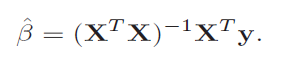

In [47]:
x_T = np.transpose(X_train.values)
xT_x = np.matmul(x_T,X_train.values)
inverse_xT_x= np.linalg.inv(xT_x) # classical way you can also use linalg.lstsq
optimum_coefficients = np.matmul((np.matmul(inverse_xT_x, x_T)), y_train.values)
#but this should produce an error bc of singular matrix


LinAlgError: Singular matrix

### Solving the error using SVD to calculate peseudo-inverse

In [50]:
def linear_reg_SVD(X, Y, zero_threshold = 1e-13):
      u, s, vT = np.linalg.svd(X, full_matrices= False)
      # Now initialize the "pseudo-"inverse of Sigma, where "pseudo" means "don't divide by zero"
      sigma_pseudo_inverse = np.zeros((vT.shape[0], vT.shape[0]))

      ## getting the index of the first approximately zero singular value
      idx_nearly_zero_sigma= np.where(s <= zero_threshold)[0][0]

      # 1/non-zero diagonal elements calculation
      sigma_pseudo_inverse[:idx_nearly_zero_sigma,:idx_nearly_zero_sigma] = np.diag(1/s[ :idx_nearly_zero_sigma])
      #the above three lines could have been calculated via:
      # sigma_pseudo_inverse = = np.linalg.pinv(np.diag(s), rcond=1e-13)

      # calculating the optimal coefficients
      optimal_coefficients = vT.T.dot(sigma_pseudo_inverse).dot(u.T).dot(Y)
      return optimal_coefficients  

In [51]:
optimal_coefficients = linear_reg_SVD(X_train, y_train, zero_threshold = 1e-13)
y_hat_from_scratch = X_train.values.dot(optimal_coefficients)

### Comparing it with Linear regression from sklearn

In [53]:
from sklearn.linear_model import LinearRegression
linreg= LinearRegression().fit(X_train,y_train)
y_hat_from_sklearn = linreg.predict(X_train)

In [54]:
y_hat_from_sklearn

array([[0.45524597],
       [0.26924133],
       [0.15576172],
       ...,
       [0.70422363],
       [0.51350403],
       [0.62333679]])

In [55]:
y_hat_from_scratch

array([[0.4554145 ],
       [0.27771016],
       [0.156025  ],
       ...,
       [0.70356874],
       [0.51260159],
       [0.62321594]])